# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

# Simulating data

## Single df

In [ ]:
# import numpy as np
# import geopandas as gpd

# from shapely.geometry import Point

# from scipy.spatial import cKDTree
# from scipy.sparse.linalg import spsolve
# from scipy.sparse import identity

# from libpysal.weights import DistanceBand

### Creating

In [2]:
gdf_output = return_spatial_geo_df3(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [5]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
127,1127,POINT (600 700),600,700,0,-0.190758,1,-0.638279,0.117423,0.592880,-0.451786,0.005915,0.883760,0.006693,400.0,0.006693,-0.612523,-0.721308
128,1128,POINT (600 800),600,800,0,0.812448,1,1.259364,0.173812,-0.893651,0.831305,0.009339,1.395427,0.006693,400.0,0.006693,0.894173,1.025083
129,1129,POINT (600 900),600,900,0,-1.348009,1,-0.687918,-2.054008,-0.204197,-0.242124,0.002865,0.428000,0.006693,400.0,0.006693,-1.692078,-1.730549
130,1130,POINT (600 1000),600,1000,0,-2.257238,1,-0.005949,-1.044384,-1.075699,-1.074200,0.004974,0.743172,0.006693,400.0,0.006693,-2.045409,-2.071739
131,1131,POINT (600 1100),600,1100,0,0.521298,1,0.098633,-0.455943,-0.773483,1.063147,0.005651,0.844312,0.006693,400.0,0.006693,0.094486,0.043909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,1569,POINT (2800 900),2800,900,0,1.363228,1,0.323201,0.710914,-1.134562,0.806623,0.009233,1.379483,0.006693,400.0,0.006693,0.863512,0.863512
570,1570,POINT (2800 1000),2800,1000,0,0.154049,1,0.268641,-0.328599,-0.569485,0.045206,0.007341,1.096822,0.006693,400.0,0.006693,-0.335932,-0.335932
571,1571,POINT (2800 1100),2800,1100,0,1.211262,1,-0.304985,0.732693,0.550357,-0.195136,0.006633,0.991113,0.006693,400.0,0.006693,0.420706,0.420706
572,1572,POINT (2800 1200),2800,1200,0,0.524587,1,0.694616,0.246542,-1.064442,0.074421,0.006810,1.017573,0.006693,400.0,0.006693,0.392346,0.392346


In [6]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [7]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7402167722008246)

In [8]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5)

In [9]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
207,1207,POINT (1000 700),1000,700,1,0.186176,1,-1.041644,1.125371,0.455003,0.056255,1.171626,1.171626,1.0,0.0,1.0,1.353642,1.325594
208,1208,POINT (1000 800),1000,800,1,-1.415570,1,-0.120666,1.169422,-0.533415,-2.120712,1.721700,1.721700,1.0,0.0,1.0,0.681053,0.567414
209,1209,POINT (1000 900),1000,900,1,-2.667943,1,-1.300878,-1.489966,-1.144192,-0.043988,0.787124,0.787124,1.0,0.0,1.0,-0.689763,-0.988959
210,1210,POINT (1000 1000),1000,1000,1,2.631740,1,0.453068,0.641973,-0.557638,1.970692,1.193402,1.193402,1.0,0.0,1.0,3.281325,3.163585
211,1211,POINT (1000 1100),1000,1100,1,-1.077536,1,-1.671232,1.432038,-0.788688,-0.879696,1.028316,1.028316,1.0,0.0,1.0,0.538101,0.179532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,2.503370,1,0.484160,1.407091,0.261174,1.349929,2.028913,2.028913,1.0,0.0,1.0,4.469538,3.970410
490,1490,POINT (2400 1000),2400,1000,1,1.785713,1,-0.991131,1.920809,-0.151181,1.447558,1.883625,1.883625,1.0,0.0,1.0,3.633984,3.183096
491,1491,POINT (2400 1100),2400,1100,1,0.727019,1,-0.027499,-0.865407,0.989064,0.709447,1.694495,1.694495,1.0,0.0,1.0,2.934126,2.487109
492,1492,POINT (2400 1200),2400,1200,1,1.585530,1,1.104153,-1.496451,1.170860,0.996962,1.508808,1.508808,1.0,0.0,1.0,2.681210,2.681210


In [10]:
gdf_output.isna().any().any()

np.False_

In [12]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.2245', 'p-value simulated: 0.0010']

#### Visual checks

In [14]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

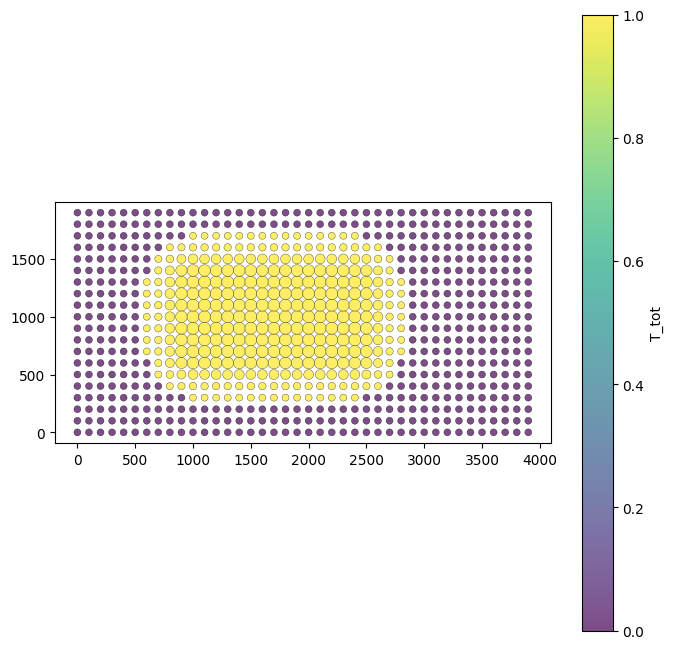

In [15]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

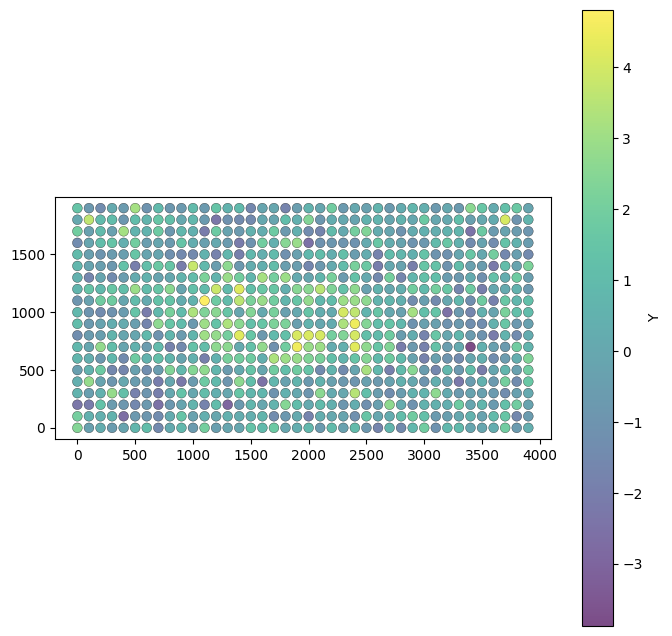

In [16]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

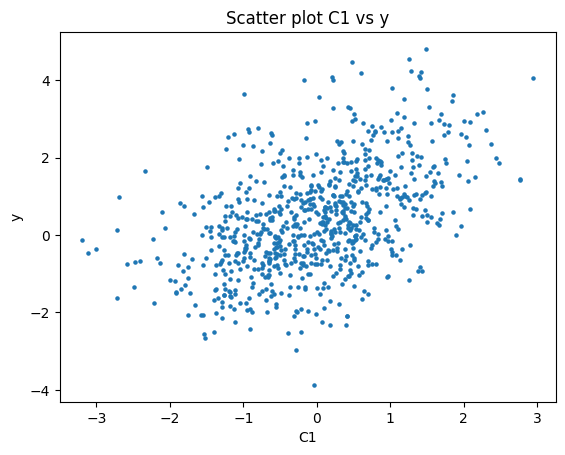

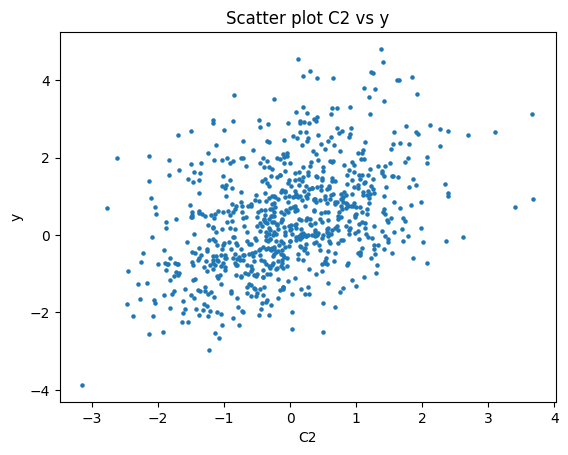

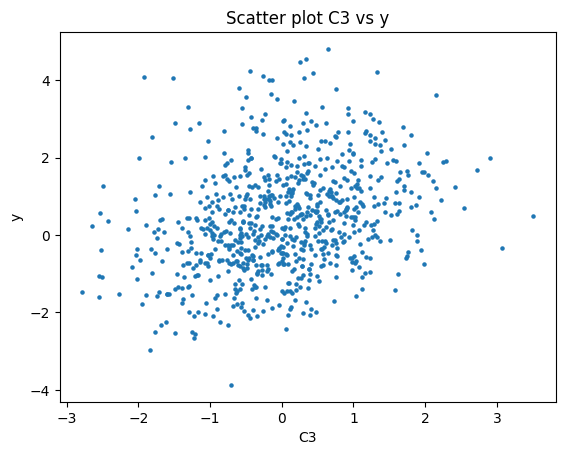

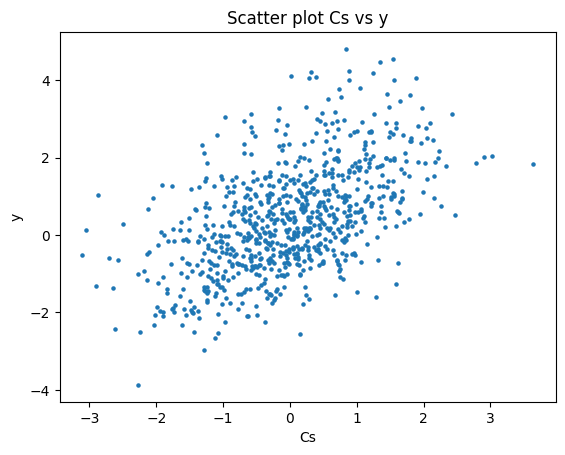

In [17]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [24]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

##### Logit for T

In [19]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.384830
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.01010
Time:                        19:22:32   Log-Likelihood:                -307.86
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                   0.04323
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9099      0.107    -17.901      0.000      -2.119      -1.701
x1            -0.1260      0.

##### Cross sectional linear difference in differences 

In [20]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     319.1
Date:                Sun, 10 May 2026   Prob (F-statistic):          5.35e-136
Time:                        19:22:53   Log-Likelihood:                -1053.1
No. Observations:                 800   AIC:                             2114.
Df Residuals:                     796   BIC:                             2133.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2240      0.034      6.517      0.0

In [22]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     244.1
Date:                Sun, 10 May 2026   Prob (F-statistic):          2.84e-112
Time:                        19:24:11   Log-Likelihood:                -1108.1
No. Observations:                 800   AIC:                             2224.
Df Residuals:                     796   BIC:                             2243.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1430      0.044      3.254      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [23]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.4235                Number of Variables   :           8
S.D. dependent var  :      1.3774                Degrees of Freedom    :         792
Pseudo R-squared    :      0.5740
Spatial Pseudo R-squared:  0.5666
Log likelihood      :  -1051.8521
Sigma-square ML     :      0.8073                Akaike info criterion :    2119.704
S.E of regression   :      0.8985                Schwarz criterion     :    2157.181

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [25]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,1.171626,1.196634
208,1208,POINT (1000 800),1,1.721700,1.312008
209,1209,POINT (1000 900),1,0.787124,0.502270
210,1210,POINT (1000 1000),1,1.193402,2.191414
211,1211,POINT (1000 1100),1,1.028316,1.168359
...,...,...,...,...,...
489,1489,POINT (2400 900),1,2.028913,1.951280
490,1490,POINT (2400 1000),1,1.883625,1.689500
491,1491,POINT (2400 1100),1,1.694495,1.769668
492,1492,POINT (2400 1200),1,1.508808,1.986407


In [26]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.5427420799614915),
 np.float64(1.5691200781714805),
 np.float64(1.5954980763814695))

In [27]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.54861130792582)

###### For T tot

In [29]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.005915,0.883760,0.592360
128,1128,POINT (600 800),1,0.009339,1.395427,1.239740
129,1129,POINT (600 900),1,0.002865,0.428000,-0.126407
130,1130,POINT (600 1000),1,0.004974,0.743172,0.910631
131,1131,POINT (600 1100),1,0.005651,0.844312,0.816116
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.009233,1.379483,0.893804
570,1570,POINT (2800 1000),1,0.007341,1.096822,1.119261
571,1571,POINT (2800 1100),1,0.006633,0.991113,0.682414
572,1572,POINT (2800 1200),1,0.006810,1.017573,0.791191


## Generating multiple df for simulations

### Data generation

In [ ]:
list_of_rhos = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 
        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,
        ATT_target = 1.5,
        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,
        rho = i,
        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,
        lambda_cs = 0.2,
        distance_ring_number = 2,
        distance_ring_ate_scalars=[0.4, 0.15],
        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:]}'] = single_gdf_output2

In [ ]:
dict_of_output_gdf.keys()

In [ ]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_55']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

### Data saving

In [ ]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [ ]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [ ]:
repo_path_r_string

In [ ]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )